In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

detecting lines

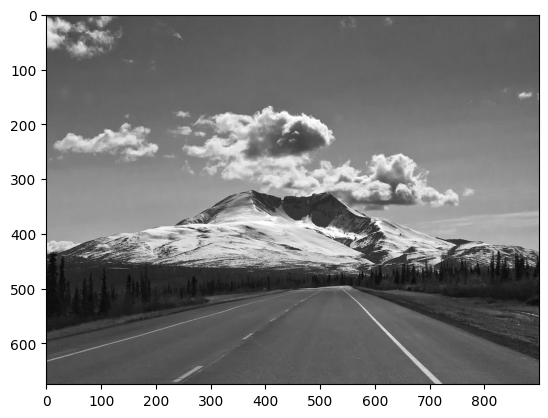

In [2]:
img = cv2.imread('images/road.jpg', 0)
plt.imshow(img, cmap='gray', vmin=0, vmax=255)

a little cheating :)

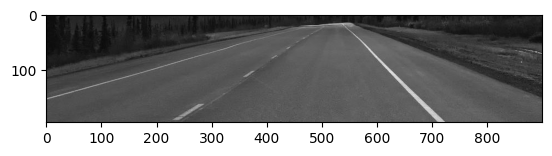

In [3]:
plt.imshow(img[480:, :], cmap='gray', vmin=0, vmax=255)

In [4]:
img = img[480:, :]

In [5]:
threshold1 = 100
threshold2 = 200

canny_edges = cv2.Canny(img, threshold1, threshold2)

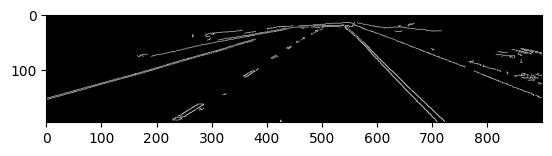

In [6]:
plt.imshow(canny_edges, cmap='gray', vmin=0, vmax=255)

In [7]:
img.shape

(195, 900)

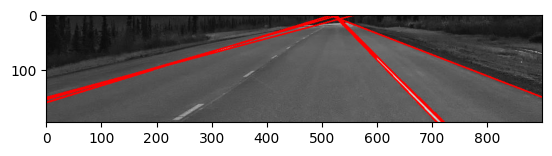

In [8]:
# image to display the results
cdst = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

# rho = x * cos(theta) + y * sin(theta)
# arguments: edge image, resolutions of rho (1 pixel) and theta (1 degree), minimum number of intersections for line detection
lines = cv2.HoughLines(canny_edges, 1, np.pi / 180, 150)

if lines is not None:
    for i in range(0, len(lines)):
        rho = lines[i][0][0]
        theta = lines[i][0][1]
        pt1 = (int(rho / math.cos(theta)), 0) # set y = 0
        pt2 = (0, int(rho / math.sin(theta))) # set x = 0
        cv2.line(cdst, pt1, pt2, (255, 0, 0), 2)
        pt1 = (int((rho - 900 * math.sin(theta)) / math.cos(theta)), 900) # set y = 900
        pt2 = (195, int((rho - 195 * math.cos(theta)) / math.sin(theta))) # set x = 195
        cv2.line(cdst, pt1, pt2, (255, 0, 0), 2)

plt.imshow(cdst)